In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

In [2]:
# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

In [3]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

In [4]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


In [5]:
len(data.loc[0, 'pixels'].split(' '))

2304

In [5]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

In [9]:
for i in range(5):
    print(faces[i, 0, 0, :])

[70. 70. 70.]
[151. 151. 151.]
[231. 231. 231.]
[24. 24. 24.]
[4. 4. 4.]


In [15]:
print(faces[0, :, :, 0])
print(f"Shape of each image: {faces[0].shape}")

[[ 70.  80.  82. ...  52.  43.  41.]
 [ 65.  61.  58. ...  56.  52.  44.]
 [ 50.  43.  54. ...  49.  56.  47.]
 ...
 [ 91.  65.  42. ...  72.  56.  43.]
 [ 77.  82.  79. ... 105.  70.  46.]
 [ 77.  72.  84. ... 106. 109.  82.]]
Shape of each image: (48, 48, 3)


In [13]:
faces[0, :, :, :2]

array([[[ 70.,  70.],
        [ 80.,  80.],
        [ 82.,  82.],
        ...,
        [ 52.,  52.],
        [ 43.,  43.],
        [ 41.,  41.]],

       [[ 65.,  65.],
        [ 61.,  61.],
        [ 58.,  58.],
        ...,
        [ 56.,  56.],
        [ 52.,  52.],
        [ 44.,  44.]],

       [[ 50.,  50.],
        [ 43.,  43.],
        [ 54.,  54.],
        ...,
        [ 49.,  49.],
        [ 56.,  56.],
        [ 47.,  47.]],

       ...,

       [[ 91.,  91.],
        [ 65.,  65.],
        [ 42.,  42.],
        ...,
        [ 72.,  72.],
        [ 56.,  56.],
        [ 43.,  43.]],

       [[ 77.,  77.],
        [ 82.,  82.],
        [ 79.,  79.],
        ...,
        [105., 105.],
        [ 70.,  70.],
        [ 46.,  46.]],

       [[ 77.,  77.],
        [ 72.,  72.],
        [ 84.,  84.],
        ...,
        [106., 106.],
        [109., 109.],
        [ 82.,  82.]]], dtype=float32)

In [6]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

In [7]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

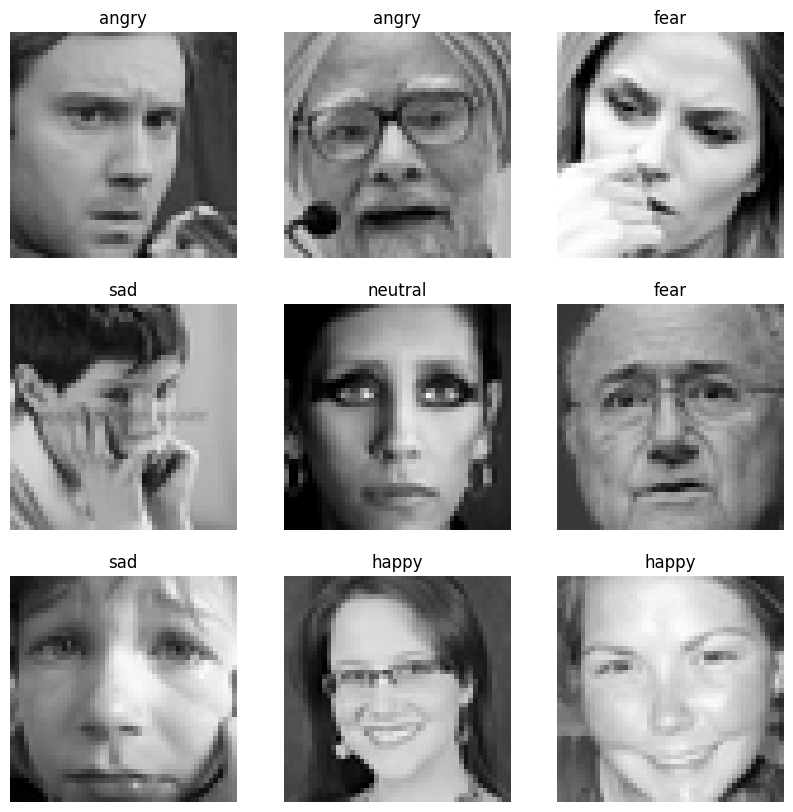

In [18]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

In [8]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

## Building the model

In [38]:
import keras
from keras import layers

input = keras.Input(shape=(48, 48, 3), name="input")

###### YOUR CODE HERE #####
x = layers.Rescaling(1.0/255)(input)
x = layers.Conv2D(filters=16, kernel_size=(2,2), activation="relu")(x)
x = layers.MaxPool2D(pool_size=2)(x)
x = layers.Conv2D(filters=16, kernel_size=(2,2), activation="relu")(x)
x = layers.MaxPool2D(pool_size=2)(x)
x = layers.Conv2D(filters=16, kernel_size=(2,2), activation="relu")(x)
x = layers.MaxPool2D(pool_size=2)(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

output = keras.layers.Dense(7, activation="softmax", name="output")(x)
###### YOUR CODE HERE #####

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import keras
from keras import layers

## Parameters calculation
```
(208 + 1040 + 1040 + 102656 + 1799 = 106743)

208 = 16 * (4 * 3 + 1)
1040 = 16 * (4 * 16 + 1)
1040 = 16 * (4 * 16 + 1)
102656 = 256 * 401
1799 = 7 * (257)
```


## Training and evaluation

In [39]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_history = model.fit(
    train_faces,
    train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3110 - loss: 1.7191 - val_accuracy: 0.3795 - val_loss: 1.6086
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3980 - loss: 1.5641 - val_accuracy: 0.4136 - val_loss: 1.5303
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4285 - loss: 1.4848 - val_accuracy: 0.4382 - val_loss: 1.4604
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4548 - loss: 1.4168 - val_accuracy: 0.4511 - val_loss: 1.4231
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4817 - loss: 1.3590 - val_accuracy: 0.4639 - val_loss: 1.3935
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5006 - loss: 1.3073 - val_accuracy: 0.4687 - val_loss: 1.3762
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5225 - loss: 1.2584 - val_accuracy: 0.4774 - val_loss: 1.3670
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5409 - loss: 1.2127 - val_accuracy: 0

**Epochs and Batches.**

In your own words, please explain the relationship between an epoch and a batch in stochastic gradient descent.

<font color='red'>**Your Answer.**</font>
A epoch is 1 cycle of training on the entire training data. For every epoch, the training will happen in batches, here there are total of 359 batches per epoch.




When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.

<font color='red'>**Your Answer.**</font>

We divide 28709 training data by batch size of 64, which gives 359 batches per epoch.

In [26]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

# plot_accuracy(model_history)

In [40]:
test_loss, test_acc = model.evaluate(test_faces, test_emotions)
print(f"Test accuracy: {test_acc:.3f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4694 - loss: 2.9153
Test accuracy: 0.469


## Wider Model

In [41]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###
x = keras.layers.Rescaling(1./255)(input) #normalizing
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
output = keras.layers.Dense(7, activation="softmax", name="output")(x)
### YOUR CODE ABOVE ###

wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

Model: "wider_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [5 points]
The model above has $215,527$ trainable parameters and is computed by $416 + 4128 + 4128 + 205056 + 1799$. Explain how each of these 5 numbers is calculated and show your computations.

<font color='red'>**Your Answer.**</font>
```
416 = 32 * (2 * 2 * 3 + 1)
4128 = 32 * (2 * 2 * 32 + 1)
205,056 = 256 * (801)
1799 = 7 * (257)
```

In [42]:
model.compile(
    loss = "categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_history = model.fit(
    train_faces,
    train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8667 - loss: 0.3681 - val_accuracy: 0.4721 - val_loss: 2.9509
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8660 - loss: 0.3668 - val_accuracy: 0.4687 - val_loss: 2.9832
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8687 - loss: 0.3613 - val_accuracy: 0.4779 - val_loss: 2.9098
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8814 - loss: 0.3312 - val_accuracy: 0.4812 - val_loss: 2.9560
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8909 - loss: 0.3043 - val_accuracy: 0.4794 - val_loss: 3.0593
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8989 - loss: 0.2847 - val_accuracy: 0.4824 - val_loss: 3.1280
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9086 - loss: 0.2544 - val_accuracy: 0.4889 - val_loss: 3.3083
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9139 - loss: 0.2414 - val_accuracy: 0

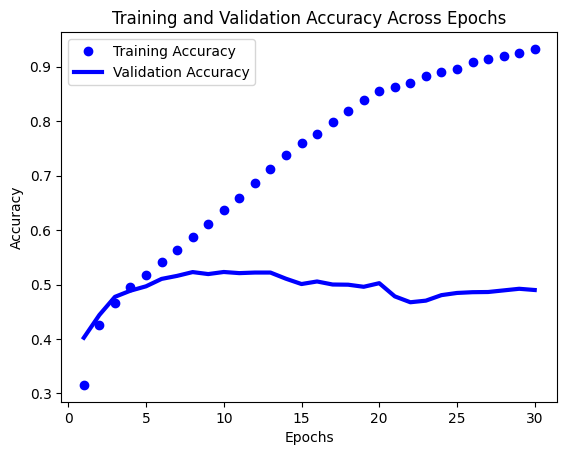

In [29]:
plot_accuracy(model_history)

In [43]:
test_loss, test_acc = model.evaluate(test_faces, test_emotions)
print(f"Test accuracy: {test_acc:.3f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4571 - loss: 5.4433
Test accuracy: 0.457


## Deeper model

In [44]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###

x = keras.layers.Rescaling(1./255)(input) #normalizing
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(256, activation="relu")(x)

output = keras.layers.Dense(7, activation="softmax", name="output")(x)

### YOUR CODE ABOVE ###

deeper_model = keras.Model(input, output, name='deeper_cnn')
deeper_model.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,535 (673.96 KB)

 Trainable params: 172,535 (673.96 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
deeper_model.compile(
    loss = "categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_history = deeper_model.fit(
    train_faces,
    train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3097 - loss: 1.7068 - val_accuracy: 0.3924 - val_loss: 1.5778
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4096 - loss: 1.5168 - val_accuracy: 0.4227 - val_loss: 1.4935
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4477 - loss: 1.4200 - val_accuracy: 0.4467 - val_loss: 1.4358
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4819 - loss: 1.3474 - val_accuracy: 0.4655 - val_loss: 1.3896
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5070 - loss: 1.2872 - val_accuracy: 0.4784 - val_loss: 1.3579
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5350 - loss: 1.2321 - val_accuracy: 0.4784 - val_loss: 1.3601
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5599 - loss: 1.1714 - val_accuracy: 0.4810 - val_loss: 1.3783
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5822 - loss: 1.1165 - val_accuracy: 0

In [33]:
deeper_model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4607 - loss: 3.7689


[3.7688517570495605, 0.46071329712867737]

In [46]:
test_loss, test_acc = deeper_model.evaluate(test_faces, test_emotions)
print(f"Test accuracy: {test_acc:.3f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4588 - loss: 3.8996
Test accuracy: 0.459


## Part (e): Comparison [10 points]
Comment on the difference between the test accuracy of `model`, `wider_model` and `deeper_model`. Did widening the model or deepening the model result in a better performance? Why? Do you think
this result generally holds true for all problems?

<font color='red'>**Your Answer**</font>

Test Accuracy Comparison:
* `model`: 46.9%
* `wider_model`: 45.7%
* `deeper_model`: 45.9%

Neither improved the performance. Maybe because of small data size. in general with more data, bigger model should perform better.

## Data augmentation

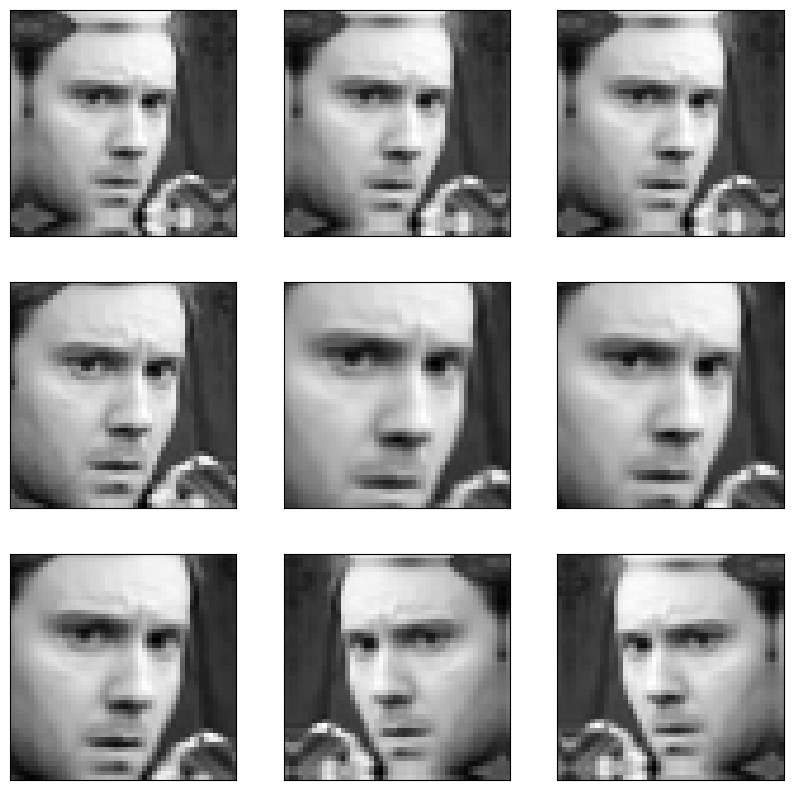

In [9]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

In [15]:
input = keras.Input(shape=(48, 48, 3))

### DATA AUGMENTATION ###
x = keras.layers.RandomFlip("horizontal")(input)
x = keras.layers.RandomZoom(0.2)(x)

x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=2, activation="relu")(x)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(filters=32, kernel_size=2, activation="relu")(x)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(filters=32, kernel_size=2, activation="relu")(x)
x = layers.MaxPool2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
output = layers.Dense(7, activation="softmax")(x)
# Please insert your code from wider_model here.

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_11 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_11 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model_augmented.compile(
    loss = "categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_augmented_history = model_augmented.fit(
    train_faces,
    train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2958 - loss: 1.7342 - val_accuracy: 0.3727 - val_loss: 1.6278
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3801 - loss: 1.5931 - val_accuracy: 0.4206 - val_loss: 1.5072
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4156 - loss: 1.5037 - val_accuracy: 0.4530 - val_loss: 1.4306
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4457 - loss: 1.4370 - val_accuracy: 0.4801 - val_loss: 1.3628
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4689 - loss: 1.3861 - val_accuracy: 0.4949 - val_loss: 1.3308
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4793 - loss: 1.3522 - val_accuracy: 0.5044 - val_loss: 1.2931
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4998 - loss: 1.3064 - val_accuracy: 0.5103 - val_loss: 1.2837
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5091 - loss: 1.2779 - val_accuracy: 

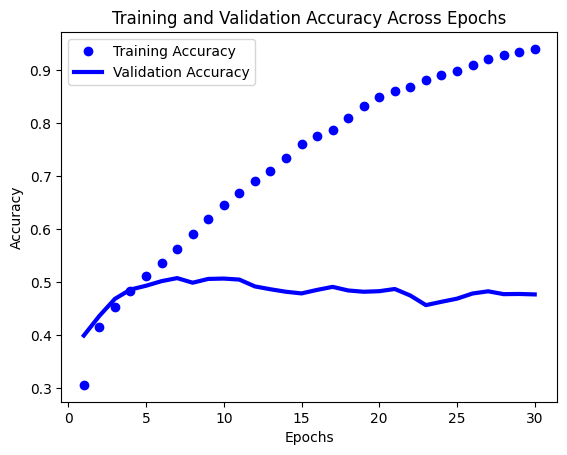

In [38]:
plot_accuracy(model_augmented_history)

In [39]:
model_augmented.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4726 - loss: 3.9173


[3.917280435562134, 0.4725550413131714]

In [17]:
test_loss, test_acc = model_augmented.evaluate(test_faces, test_emotions)
print(f"Test accuracy: {test_acc:.3f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5581 - loss: 1.2338
Test accuracy: 0.558


Compare this with `wider_model` and comment on the impact of data augmentation.

* Did data augmentation reduce overfitting?
* Did data augmentation improve test set accuracy

<font color='red'> **Your Answer.** </font>

_Please replace this text with your answer_

## Transfer Learning and Fine-Tuning

In [4]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [5]:
inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Use the base_model as a whole, not layer by layer
x = base_model(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='transfer_model')
transfer_model.summary()

Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [14]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.2541 - loss: 1.8019 - val_accuracy: 0.2978 - val_loss: 1.7350
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.3033 - loss: 1.7252 - val_accuracy: 0.3292 - val_loss: 1.6880
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3206 - loss: 1.6969 - val_accuracy: 0.3363 - val_loss: 1.6645
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3292 - loss: 1.6811 - val_accuracy: 0.3438 - val_loss: 1.6504
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3376 - loss: 1.6675 - val_accuracy: 0.3478 - val_loss: 1.6405
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3424 - loss: 1.6602 - val_accuracy: 0.3525 - val_loss: 1.6326
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3452 - loss: 1.6530 - val_accuracy: 0.3567 - val_loss: 1.6255
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3461 - loss: 1.6479 - 

In [17]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

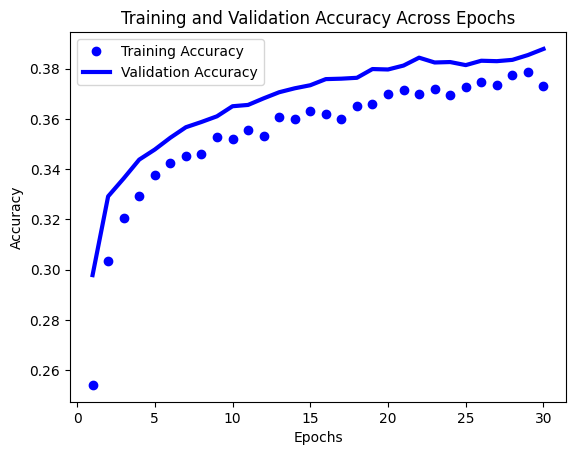

In [18]:
plot_accuracy(transfer_model_history)

In [20]:
test_loss, test_acc = transfer_model.evaluate(test_faces, test_emotions)
print(f"Test accuracy: {test_acc:.3f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3794 - loss: 1.5764
Test accuracy: 0.379


## Fine tuning

In [22]:
from keras import layers, Model, Input
from keras.applications import VGG19

# Load pretrained VGG19
base_model = VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(48, 48, 3)
)

# IMPORTANT: allow fine-tuning control
base_model.trainable = True

# Freeze first 15 layers of VGG19
for layer in base_model.layers[:15]:
    layer.trainable = False

# Input pipeline
inputs = Input(shape=(48, 48, 3))

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomZoom(0.2)(x)
x = layers.Rescaling(1./255)(x)

# Pass through full VGG19 properly (DO NOT loop layer-by-layer)
x = base_model(x, training=False)

# Classification head
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(7, activation='softmax')(x)

partial_model = Model(inputs, outputs, name='partial_fine_tune_model')

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_16 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_16 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 11,932,167 (45.52 MB)

 Non-trainable params: 8,225,344 (31.38 MB)

In [23]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_12 (InputLayer), Trainable=True
Layer 2: random_flip_16 (RandomFlip), Trainable=True
Layer 3: random_zoom_16 (RandomZoom), Trainable=True
Layer 4: rescaling_4 (Rescaling), Trainable=True
Layer 5: vgg19 (Functional), Trainable=True
Layer 6: flatten_6 (Flatten), Trainable=True
Layer 7: dense_12 (Dense), Trainable=True
Layer 8: dense_13 (Dense), Trainable=True


In [24]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3916 - loss: 1.5538 - val_accuracy: 0.4808 - val_loss: 1.3801
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.4703 - loss: 1.3852 - val_accuracy: 0.4993 - val_loss: 1.3052
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.5018 - loss: 1.3004 - val_accuracy: 0.5150 - val_loss: 1.2638
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.5295 - loss: 1.2274 - val_accuracy: 0.5207 - val_loss: 1.2504
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.5586 - loss: 1.1682 - val_accuracy: 0.5406 - val_loss: 1.2027
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.5789 - loss: 1.1124 - val_accuracy: 0.5474 - val_loss: 1.1922
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6008 - loss: 1.0618 - val_accuracy: 0.5536 - val_loss: 1.1790
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.6246 - loss: 1.0100 - 

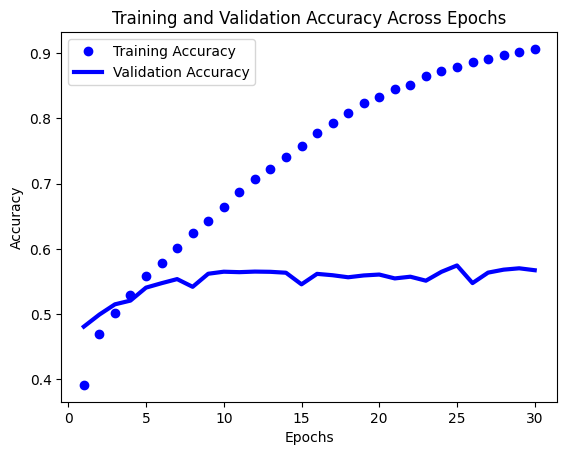

In [27]:
plot_accuracy(partial_model_history)

In [29]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
*************************
* Test Accuracy: 0.5737 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,435,5,104,99,208,17,90
disgust,28,49,11,7,13,0,3
fear,104,2,471,70,246,45,86
happy,53,5,54,1406,121,14,121
sad,103,3,144,146,710,11,130
surprise,41,0,121,66,61,497,45
neutral,88,0,121,170,293,11,550


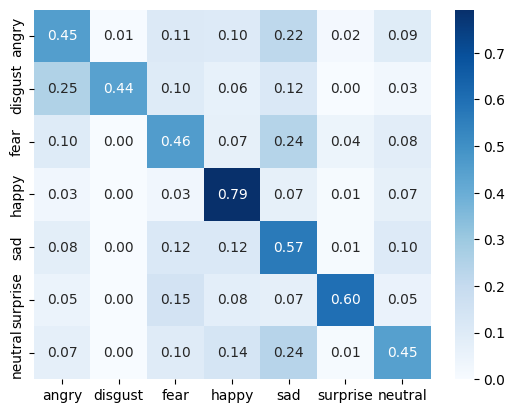

In [30]:
show_confusion_matrix(partial_model)